# Knowledge Graph (KG) + Graph Neural Network (GNN) Implementation for On-device Predictive Model

This approach is an alternative to the XGBoost + LSTM-based pipeline. Here, KG is utilized to map all the relationships between the various entities. For example:
  
A user ---uses--> a device.

These types of data mappings are very well suited for the given dataset.

### Dataset Used:
Samsung SmartThings Internet of Things (IoT) datasets. https://github.com/snudatalab/smartsense


## The main pipeline:
  
SmartThings Logs -> Data Preprocessing -> KG construction -> Graph Embedding / GNN Model -> Device Priority Prediction -> Ranked Device List


---
## 1. Setup and Imports

In [1]:
!pip install pandas
!pip install networkx
!pip install node2vec
!pip install tensorflow
!pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import pickle
import tensorflow as tf

from node2vec import Node2Vec
from sklearn.model_selection import train_test_split

---
## 2. Load the SmartThings Dataset

In [3]:
with open("trn_instance_10.pkl", "rb") as f: # fr training example taken
    data = pickle.load(f)

print(len(data))
print(data[0])

199786
[[  4   7  33   1 245]
 [  5   3  33   1 245]
 [  5   4  33   0 244]
 [  6   0  33   1 245]
 [  6   4  33   0 244]
 [  6   7  33   1 245]
 [  0   1  33   0 244]
 [  0   3  33   1 245]
 [  0   4  33   0 244]
 [  1   3  33   1 245]]


Here, each action is:

    [day_of_week, hour, device, control, device_control]

---
## 3. Data Preprocessing

Here we flatten each sequence and store them as dictionaries for the Knowledge Graph.

In [4]:
records = []

for seq in data:
    for action in seq:
        records.append({
            "day": action[0],
            "hour": action[1],
            "device": action[2],
            "control": action[3],
            "device_control": action[4]
        })

df = pd.DataFrame(records)

df.head()

,day,hour,device,control,device_control
0,4,7,33,1,245
1,5,3,33,1,245
2,5,4,33,0,244
3,6,0,33,1,245
4,6,4,33,0,244


---
## 4. Building the Knowledge Graph

In [5]:
G = nx.Graph()

for _, row in df.iterrows():

    device = f"device_{row['device']}"
    control = f"control_{row['control']}"
    hour = f"hour_{row['hour']}"
    day = f"day_{row['day']}"

    G.add_edge(device, control)
    G.add_edge(device, hour)
    G.add_edge(device, day)

In [6]:
print("Nodes:", len(G.nodes))
print("Edges:", len(G.edges))

Nodes: 81
Edges: 816


##5. Graph Visualization

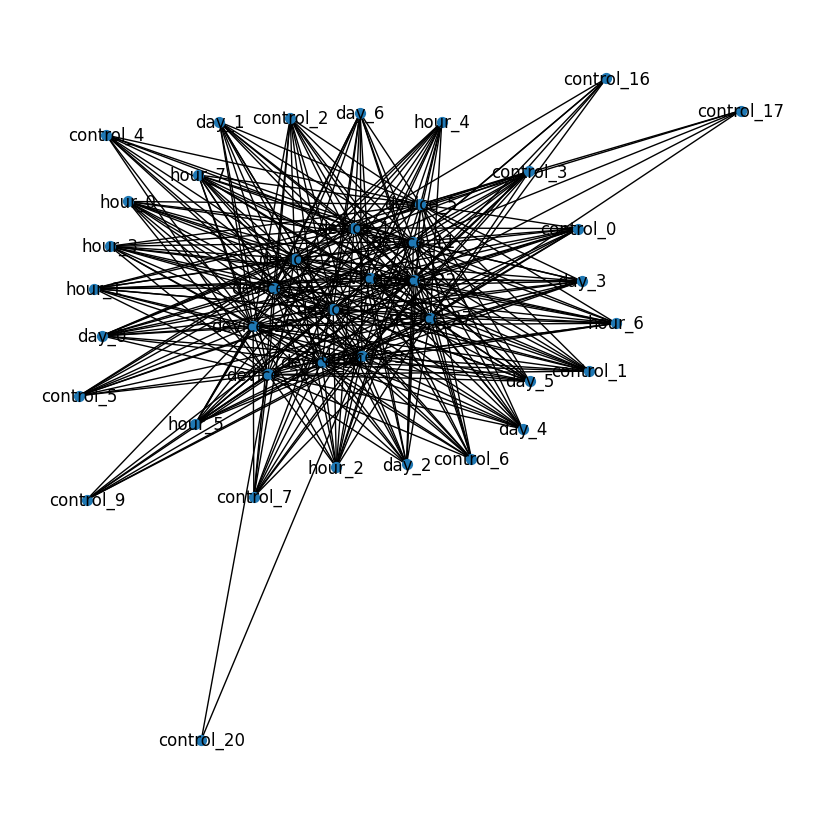

In [7]:
import matplotlib.pyplot as plt

sub_nodes = list(G.nodes)[:40]
subgraph = G.subgraph(sub_nodes)

plt.figure(figsize=(8,8))
nx.draw(subgraph, with_labels=True, node_size=50)
plt.show()

## 6. Generate Graph Embeddings

In [35]:
node2vec = Node2Vec(
    G,
    dimensions=32,
    walk_length=10,
    num_walks=100,
    workers=2
)

node2vec_model = node2vec.fit(window=5, min_count=1)

Computing transition probabilities:   0%|          | 0/81 [00:00<?, ?it/s]

##7. Extract Device Embeddings

In [36]:
device_embeddings = {}

for node in G.nodes():
    if node.startswith("device_"):
        device_embeddings[node] = node2vec_model.wv[node]

print(len(device_embeddings))

27


In [ ]:
num_devices = df["device"].nunique()
embedding_dim = 32

device_embedding_matrix = np.zeros((num_devices, embedding_dim))

for node, emb in device_embeddings.items():
    device_id = int(node.split("_")[1])
    if device_id < num_devices:
        device_embedding_matrix[device_id] = emb



## 8. Create Device Priority Dataset

In [44]:
from sklearn.preprocessing import LabelEncoder

X = []
y = []

for seq in data:

    input_seq = seq[:9]     # first 9 actions
    target = seq[9][2]      # device of the 10th action

    X.append(input_seq)
    y.append(target)

X = np.array(X)
y = np.array(y)


# to normalize y
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
sequence_length = 3

X_seq = []
y_seq = []

devices = df["device"].values

for i in range(len(devices) - sequence_length):
    X_seq.append(devices[i:i+sequence_length])
    y_seq.append(devices[i+sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

## 9. Train/Test Split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 10. Build Keras Ranking Model

In [48]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(9,5)),
    tf.keras.layers.Dense(32, activation="relu", input_shape=(X.shape[1],)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(num_devices, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3)
    ]
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
inputs = tf.keras.Input(shape=(sequence_length,))

embedding_layer = tf.keras.layers.Embedding(
    input_dim=num_devices,
    output_dim=embedding_dim,
    weights=[device_embedding_matrix],
    trainable=False
)

x = embedding_layer(inputs)

x = tf.keras.layers.MultiHeadAttention(
    num_heads=4,
    key_dim=embedding_dim
)(x, x)

x = tf.keras.layers.GlobalAveragePooling1D()(x)

x = tf.keras.layers.Dense(64, activation="relu")(x)

outputs = tf.keras.layers.Dense(num_devices, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3)
    ]
)

##11. Train Model

In [49]:
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

model.evaluate(X_test, y_test)

Epoch 1/10
3996/3996 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.6420 - loss: 2.4743 - sparse_top_k_categorical_accuracy: 0.7628 - val_accuracy: 0.7238 - val_loss: 1.0614 - val_sparse_top_k_categorical_accuracy: 0.8463
Epoch 2/10
3996/3996 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7263 - loss: 1.0573 - sparse_top_k_categorical_accuracy: 0.8596 - val_accuracy: 0.7513 - val_loss: 0.9832 - val_sparse_top_k_categorical_accuracy: 0.8660
Epoch 3/10
3996/3996 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7499 - loss: 0.9801 - sparse_top_k_categorical_accuracy: 0.8768 - val_accuracy: 0.7657 - val_loss: 0.9211 - val_sparse_top_k_categorical_accuracy: 0.8878
Epoch 4/10
3996/3996 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7693 - loss: 0.9181 - sparse_top_k_categorical_accuracy: 0.8906 - val_accuracy: 0.7743 - val_loss: 0.8918 - val_sparse_top_k_categorical_accuracy: 0.8980
Epoch 5/10
3996/3996 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.7751 - loss: 0.8857 - sparse_top_k_cate

[0.821455717086792, 0.78692626953125, 0.9107062220573425]

In [50]:
print(X_train.shape)
print(y_train.shape)

print(np.isnan(X_train).any())
print(np.isinf(X_train).any())

print(y_train.max())
print(y_train.min())

(159828, 9, 5)
(159828,)
False
False
26
0


## 12. Predict Device Priority

In [51]:
scores = model.predict(X)

devices = df["device"].unique()

ranking = sorted(
    zip(devices, scores),
    key=lambda x: x[1].max(),
    reverse=True
)

print("Device Priority Ranking")

for r in ranking[:10]:
    print(r)

6244/6244 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
Device Priority Ranking
(25, array([2.8419229e-03, 6.8764538e-03, 2.2784199e-03, 9.2292910e-05,
       2.0404292e-05, 2.6678346e-04, 4.2305859e-05, 1.3227058e-03,
       7.6120632e-05, 3.8521815e-04, 2.8361857e-05, 1.1377166e-03,
       2.3482083e-03, 1.2748450e-04, 6.5647310e-04, 1.4044865e-03,
       1.6920366e-03, 2.7720357e-04, 1.5205807e-04, 3.3852593e-03,
       3.4918834e-02, 3.7040008e-04, 2.3593153e-03, 3.7128993e-03,
       9.3107659e-01, 1.4644461e-03, 6.8555435e-04], dtype=float32))
(33, array([2.9394161e-03, 6.9711637e-03, 2.1061855e-03, 9.3510796e-05,
       2.1176222e-05, 2.2483733e-04, 4.3739445e-05, 1.3810600e-03,
       7.9134770e-05, 3.4105516e-04, 2.7427572e-05, 1.0419823e-03,
       2.1489412e-03, 1.2412801e-04, 6.0493435e-04, 1.1456882e-03,
       1.6683224e-03, 2.9365456e-04, 1.6629722e-04, 3.6996587e-03,
       3.6052573e-02, 3.9758108e-04, 2.3773492e-03, 3.5996693e-03,
       9.3019837e-01, 1.5815513e-03, 6.7054009e-0

##13. Convert To TensorFlow Lite

In [52]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open("device_priority_gnn.tflite","wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpu78rg7oq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 9, 5), dtype=tf.float32, name='keras_tensor_31')
Output Type:
  TensorSpec(shape=(None, 27), dtype=tf.float32, name=None)
Captures:
  135595699107600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135595699108368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135595699108176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135595699104912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135595699108944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135595699108560: TensorSpec(shape=(), dtype=tf.resource, name=None)
